# YOLO26 Vehicle Detection - Train/Test/Analysis

Complete training pipeline for YOLO26 on custom vehicle dataset.



**Workflow:**
1. Install dependencies
2. Auto-detect environment (Colab or local)
3. Locate dataset from annotationsv1
4. Prepare train/val/test split
5. Create data.yaml (matches classes.txt)
6. Train YOLOv8 model
7. Visualize training progression
8. Save trained weights
9. Evaluate on test set
10. Display confusion matrices
11. Display GT vs. Pred
12. Export to ONNX format


Skip step 3-5 if "yolo_dataset" folder exists. Running it again will create a new folder with a new train/val/test split.

There is not seperate cells for YOLO26n and YOLO26m. Change directory by substituting n/m in the code.

Install Dependencies

### Install all required packages
This cell needs to be re-run after running it once and restarting session.

In [1]:
import subprocess
import sys

# First, upgrade pip and setuptools
print('Upgrading pip and setuptools...')
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade', '-q', 'pip', 'setuptools'])

# Downgrade numpy to avoid _blas_supports_fpe error
print('Installing numpy <2.0 (required for compatibility)...')
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'numpy<2.0', '--force-reinstall'])

# Update scikit-learn to latest
print('Installing scikit-learn (latest)...')
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '--upgrade', 'scikit-learn'])

# Install ultralytics
print('Installing ultralytics...')
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'ultralytics>=8.0.0'])

# Then install other packages
packages = [
    'pillow',
    'matplotlib',
    'pyyaml'
]

for pkg in packages:
    print(f'Installing {pkg}...')
    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
    except:
        print(f'Installation issue with {pkg}, continuing...')

print('All dependencies installed!')

# Verify imports work
try:
    from sklearn.model_selection import train_test_split
    import numpy as np
    print(f'scikit-learn imported successfully')
    print(f'numpy {np.__version__} (compatible)')
except Exception as e:
    print(f'! Error: {e}')
    print('Try restarting the kernel and running this cell again.')


Upgrading pip and setuptools...
Installing numpy <2.0 (required for compatibility)...
Installing scikit-learn (latest)...
Installing ultralytics...
Installing pillow...
Installing matplotlib...
Installing pyyaml...
All dependencies installed!
scikit-learn imported successfully
numpy 2.4.4 (compatible)


##Detect Environment and Initialize

In [2]:
import sys
import os
from pathlib import Path

# Check environment
IS_COLAB = 'google.colab' in sys.modules

if IS_COLAB:
    print('✓ Google Colab detected')
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    print('✓ Google Drive mounted')
else:
    print('✓ Local environment detected')

print(f'Python: {sys.version.split()[0]}')

✓ Google Colab detected
Mounted at /content/drive
✓ Google Drive mounted
Python: 3.12.13


# Data preperation (skip)
The labeled dataset is already stored in the "yolo_dataset" folder. Skip to training.

In [ ]:
from pathlib import Path

# Find annotations dataset
if IS_COLAB:
    # Search in Google Drive
    drive_base = Path('/content/drive/MyDrive')
    found_paths = list(drive_base.rglob('annotations'))
    if found_paths:
        dataset_path = found_paths[0]
        print(f'✓ Found dataset: {dataset_path}')
    else:
        print('✗ annotations not found in Google Drive')
        dataset_path = None
else:
    # Local: check current directory
    dataset_path = Path('annotations')
    if dataset_path.exists():
        print(f'✓ Found dataset: {dataset_path.absolute()}')
    else:
        print(f'✗ annotations not found at {dataset_path.absolute()}')
        dataset_path = None

# Verify dataset structure
if dataset_path and dataset_path.exists():
    images = dataset_path / 'images'
    labels = dataset_path / 'labels'
    classes_file = dataset_path / 'classes.txt'

    print(f'\nDataset check:')
    print(f'  images: {images.exists()} ({len(list(images.glob("*")))} files)' if images.exists() else '  images: ✗')
    print(f'  labels: {labels.exists()} ({len(list(labels.glob("*.txt")))} files)' if labels.exists() else '  labels: ✗')
    print(f'  classes.txt: {classes_file.exists()}' if classes_file else '  classes.txt: ✗')

✓ Found dataset: /content/drive/MyDrive/Fine-tuning/annotations

Dataset check:
  images: True (1282 files)
  labels: True (1282 files)
  classes.txt: True


## Train/Val/Test Split

In [ ]:
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split
import random

if dataset_path is None:
    print('✗ Dataset not found - cannot proceed')
else:
    # Setup
    random.seed(42)
    work_dir = Path('/content/drive/MyDrive/yolo_dataset')
    if work_dir.exists():
        shutil.rmtree(work_dir)
        print('Removed old yolo_dataset')

    # Create folders
    for split in ['train', 'val', 'test']:
        (work_dir / split / 'images').mkdir(parents=True, exist_ok=True)
        (work_dir / split / 'labels').mkdir(parents=True, exist_ok=True)

    # Get images and filter by those with labels
    images_dir = dataset_path / 'images'
    labels_dir = dataset_path / 'labels'

    all_images = list(images_dir.glob('*'))
    valid_images = []
    for img in all_images:
        label_file = labels_dir / (img.stem + '.txt')
        if label_file.exists():
            valid_images.append(img)

    print(f'Found {len(valid_images)} images with labels')

    if len(valid_images) > 0:
        # Split: 70/15/15
        train_imgs, temp = train_test_split(valid_images, test_size=0.3, random_state=42)
        val_imgs, test_imgs = train_test_split(temp, test_size=0.5, random_state=42)

        print(f'  Train: {len(train_imgs)}, Val: {len(val_imgs)}, Test: {len(test_imgs)}')

        # Copy files
        for split_name, split_imgs in [('train', train_imgs), ('val', val_imgs), ('test', test_imgs)]:
            for img_path in split_imgs:
                shutil.copy2(img_path, work_dir / split_name / 'images' / img_path.name)
                label_src = labels_dir / (img_path.stem + '.txt')
                label_dst = work_dir / split_name / 'labels' / (img_path.stem + '.txt')
                shutil.copy2(label_src, label_dst)

        print('✓ Dataset prepared')

Found 1282 images with labels
  Train: 897, Val: 192, Test: 193
✓ Dataset prepared


## Verify data structure

In [ ]:
from pathlib import Path

work_dir = Path('/content/drive/MyDrive/yolo_dataset')

# Verify preparation
if work_dir.exists():
    print('✓ Dataset structure verified:')
    for split in ['train', 'val', 'test']:
        images = len(list((work_dir / split / 'images').glob('*')))
        labels = len(list((work_dir / split / 'labels').glob('*.txt')))
        print(f'  {split}: {images} images, {labels} labels')
else:
    print('✗ yolo_dataset not found - run Step 3 first')

✓ Dataset structure verified:
  train: 897 images, 897 labels
  val: 192 images, 192 labels
  test: 193 images, 193 labels


## Create data.yaml

In [ ]:
import yaml
from pathlib import Path

# Classes MUST match classes.txt order (0-indexed)
classes = [
    'bicycle',
    'bus',
    'car',
    'heavy truck',
    'light truck',
    'motorcycle',
    'person',
    'semi-trailer / combination vehicle'
]

work_dir = Path('/content/drive/MyDrive/yolo_dataset')

data_config = {
    'path': str(work_dir.absolute()),
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'nc': len(classes),
    'names': classes
}

yaml_path = work_dir / 'data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False, sort_keys=False)

print(f'✓ Created data.yaml')
print(f'\nClasses ({len(classes)}):')
for i, cls in enumerate(classes):
    print(f'  {i}: {cls}')

✓ Created data.yaml

Classes (8):
  0: bicycle
  1: bus
  2: car
  3: heavy truck
  4: light truck
  5: motorcycle
  6: person
  7: semi-trailer / combination vehicle


# Train YOLO26 Model

Fine-tuning YOLO26 on your custom vehicle classes.

In [ ]:
from ultralytics import YOLO
from pathlib import Path

work_dir = Path('/content/drive/MyDrive/yolo_dataset')
yaml_path = work_dir / 'data.yaml'
save_dir = Path('/content/drive/MyDrive/yolo26m_results') # or yolo26n_results

if not yaml_path.exists():
    print('✗ data.yaml not found - run Step 4 first')
else:
    # Train from scratch
    print("Loading fresh YOLO26m model...")
    model = YOLO('yolo26m.pt') # or YOLO26n.pt

    # Device: GPU in Colab, CPU locally
    device = 0 if IS_COLAB else 'cpu'
    print(f'Device: {device}')

    print('\nTraining from scratch...')
    results = model.train(
        data=str(yaml_path),
        epochs=100,
        imgsz=640,
        batch=16,
        patience=20,
        save=True,
        device=device,
        project=str(save_dir),
        name='vehicle_model',
        exist_ok=True,
        seed=42,
    )

    print('\n✓ Training complete')

Loading fresh YOLO26m model...
Device: 0

Training from scratch...
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=vehicle_model, nbs=64,

## Print and save training results.
Train both model sizes before running the cell for comparion charts.

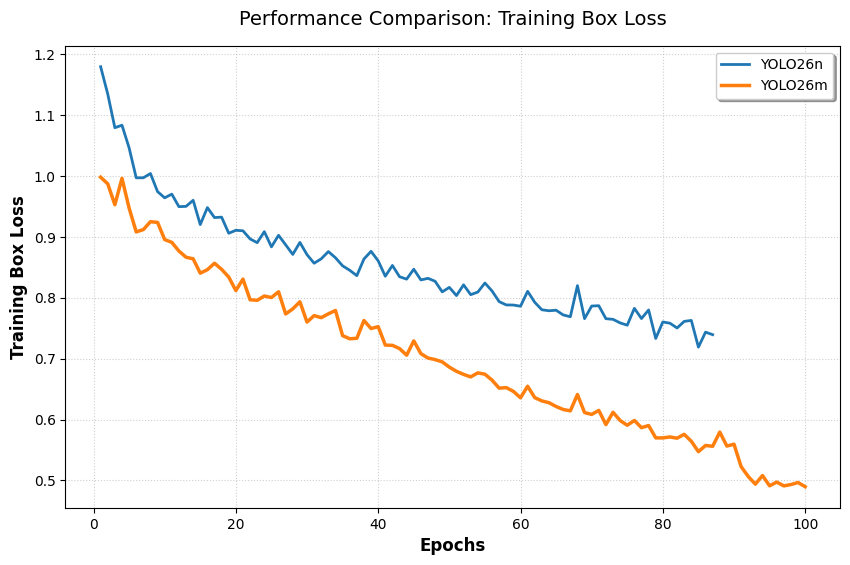

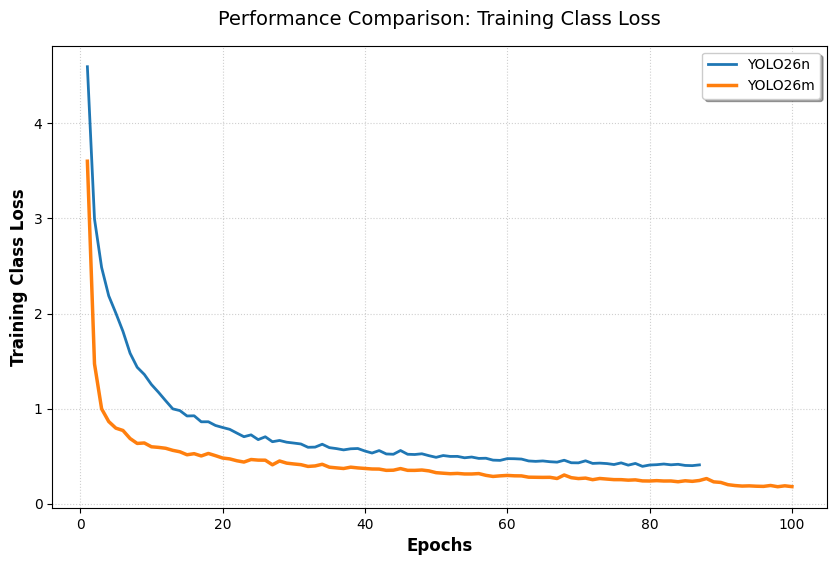

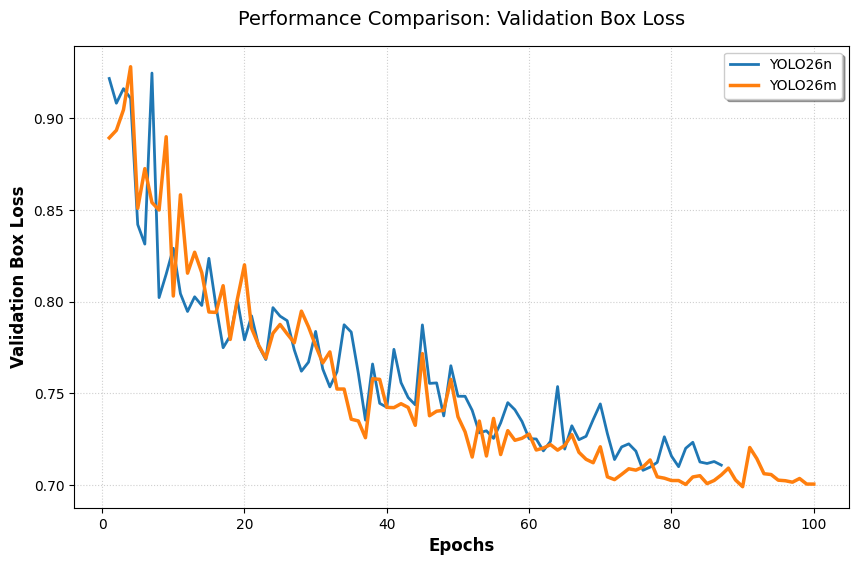

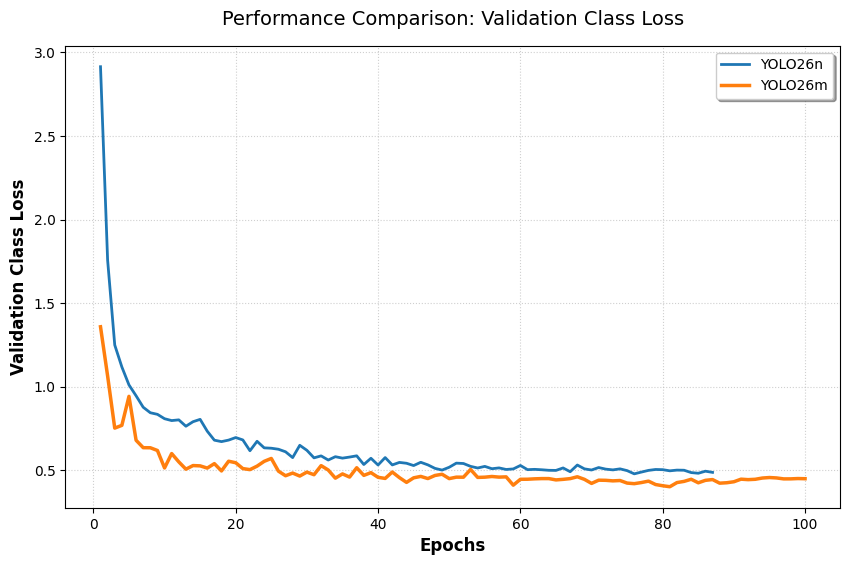

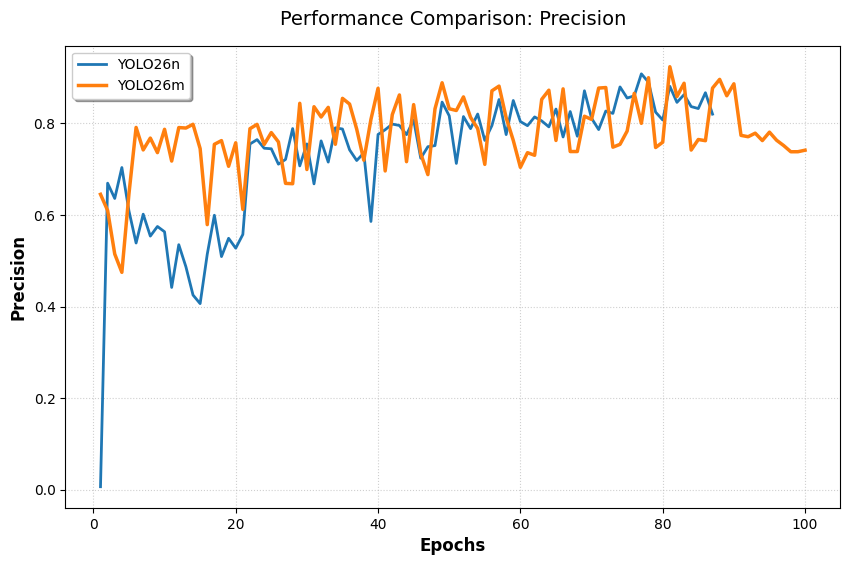

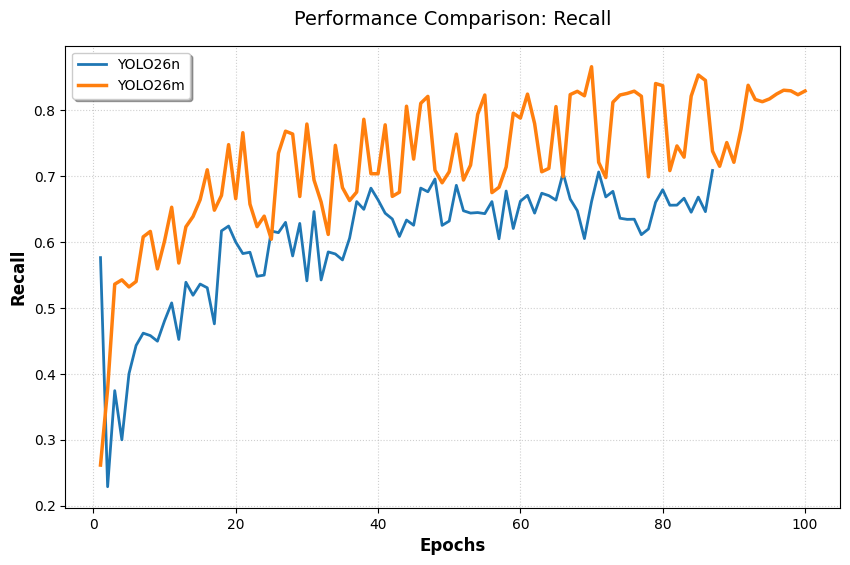

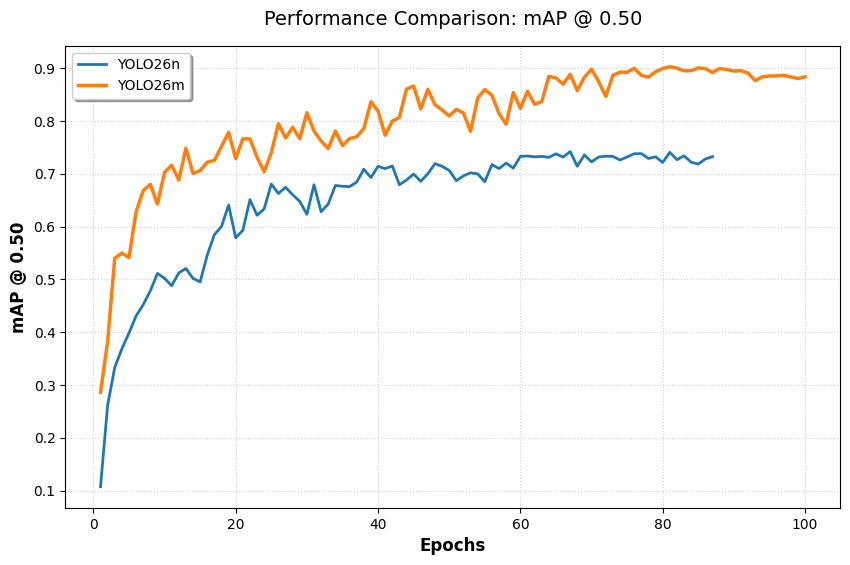

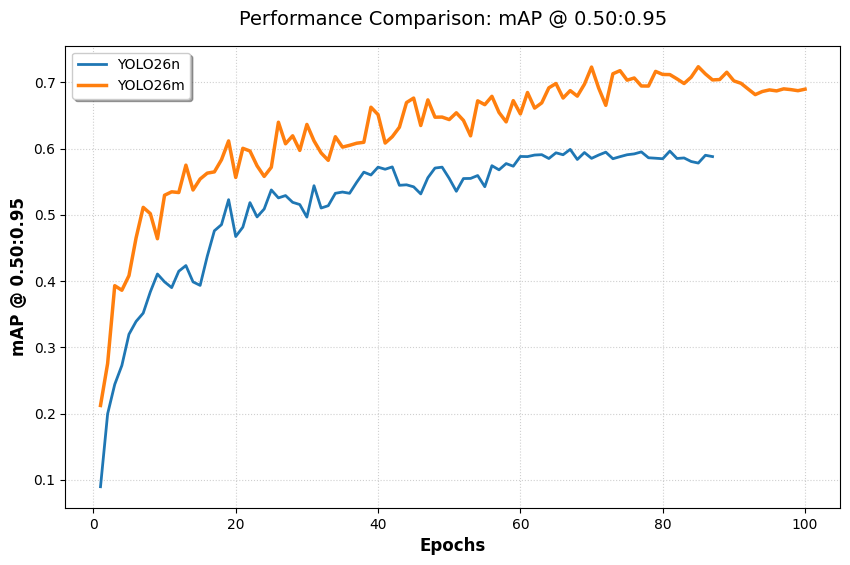

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the results
df_n = pd.read_csv('/content/drive/MyDrive/yolo26n_results/vehicle_model/results.csv')
df_m = pd.read_csv('/content/drive/MyDrive/yolo26m_results/vehicle_model/results.csv')

# 2. Clean column names
df_n.columns = [c.strip() for c in df_n.columns]
df_m.columns = [c.strip() for c in df_m.columns]

# 3. Metrics to plot
metrics = [
    ('train/box_loss', 'Training Box Loss'),
    ('train/cls_loss', 'Training Class Loss'),
    ('val/box_loss', 'Validation Box Loss'),
    ('val/cls_loss', 'Validation Class Loss'),
    ('metrics/precision(B)', 'Precision'),
    ('metrics/recall(B)', 'Recall'),
    ('metrics/mAP50(B)', 'mAP @ 0.50'),
    ('metrics/mAP50-95(B)', 'mAP @ 0.50:0.95')
]

for column, display_name in metrics:
    plt.figure(figsize=(10, 6))

    # Plot YOLO26n - SOLID BLUE LINE
    plt.plot(df_n['epoch'], df_n[column], label='YOLO26n', linewidth=2, color='#1f77b4', linestyle='-')

    # Plot YOLO26m - SOLID ORANGE LINE
    plt.plot(df_m['epoch'], df_m[column], label='YOLO26m', linewidth=2.5, color='#ff7f0e', linestyle='-')

    # Formatting
    plt.xlabel('Epochs', fontsize=12, fontweight='bold')
    plt.ylabel(display_name, fontsize=12, fontweight='bold')
    plt.title(f'Performance Comparison: {display_name}', fontsize=14, pad=15)

    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(frameon=True, loc='best', shadow=True)

    # Save logic
    clean_name = column.replace('/', '_').replace('(', '').replace(')', '')
    filename = f"comparison_{clean_name}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')

    plt.show()
    plt.close()

## Save best weights from training

In [ ]:
import shutil
from pathlib import Path

best_src = Path('/content/drive/MyDrive/yolo26m_results/vehicle_model/weights/best.pt')

best_dst = Path('/content/drive/MyDrive/yolo26m_results/YOLO26m_final.pt')

if best_src.exists():
    shutil.copy2(best_src, best_dst)
    print(f'✓ Saved best model to {best_dst.name}')
else:
    print('✗ best.pt not found')

✓ Saved best model to YOLO26m_final.pt


## Evaluate Model on Test Set

In [3]:
from ultralytics import YOLO
from pathlib import Path
import time
import matplotlib.pyplot as plt
import cv2
import numpy as np

best_model_path = Path('/content/drive/MyDrive/yolo26m_results/YOLO26m_final.pt')

if not best_model_path.exists():
    print('✗ best.pt not found - run Step 5 first')
else:
    print('Loading best model...')
    model = YOLO(str(best_model_path))

    work_dir = Path('/content/drive/MyDrive/yolo_dataset')
    yaml_path = work_dir / 'data.yaml'
    device = 0  # GPU device

    print('\n=== Validation Set Results ===')
    val_results = model.val(data=str(yaml_path), split='val', device=device)
    print(f'Summary - mAP50: {val_results.box.map50:.4f}, mAP50-95: {val_results.box.map:.4f}')

    print('\n=== Test Set Results ===')
    test_results = model.val(data=str(yaml_path), split='test', device=device, plots=True)
    print(f'\nSummary:')
    print(f'  mAP50: {test_results.box.map50:.4f}')
    print(f'  mAP50-95: {test_results.box.map:.4f}')
    print(f'  Precision: {test_results.box.mp:.4f}')
    print(f'  Recall: {test_results.box.mr:.4f}')
    print('\n(Per-class metrics shown in table)')

    # Speed estimate from Ultralytics timing (ms per image -> FPS)
    speed = test_results.speed
    total_ms = speed.get('preprocess', 0) + speed.get('inference', 0) + speed.get('postprocess', 0)
    if total_ms > 0:
        print('\n=== FPS Estimate (from test speed) ===')
        print(f"  preprocess: {speed.get('preprocess', 0):.2f} ms/img")
        print(f"  inference : {speed.get('inference', 0):.2f} ms/img")
        print(f"  postprocess: {speed.get('postprocess', 0):.2f} ms/img")
        print(f"  Estimated FPS: {1000.0 / total_ms:.2f}")

    # Real measured FPS on test images
    test_dir = work_dir / 'test' / 'images'
    test_images = sorted([p for p in test_dir.glob('*') if p.is_file()])

    if len(test_images) == 0:
        print('\n✗ No test images found for FPS benchmark')
    else:
        _ = model.predict(source=str(test_images[0]), device=device, imgsz=640, conf=0.25, verbose=False)
        start = time.perf_counter()
        for img in test_images:
            _ = model.predict(source=str(img), device=device, imgsz=640, conf=0.25, verbose=False)
        elapsed = time.perf_counter() - start
        fps = len(test_images) / elapsed if elapsed > 0 else 0

        print('\n=== Real FPS (measured on test images) ===')
        print(f'  Images: {len(test_images)}')
        print(f'  Time: {elapsed:.2f}s')
        print(f'  FPS: {fps:.2f}')



Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Loading best model...

=== Validation Set Results ===
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,355,620 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access ✅ (ping: 0.8±0.4 ms, read: 2.3±5.0 MB/s, size: 28.1 KB)
val: Scanning /content/drive/MyDrive/yolo_dataset/val/labels.cache... 192 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 192/192 28.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 1.8it/s 6.9s
                   all        192        683      0.765      0.853        0.9      0.721
               bicycle 

## Generate Confusion Matrices
Both raw and row-normalized


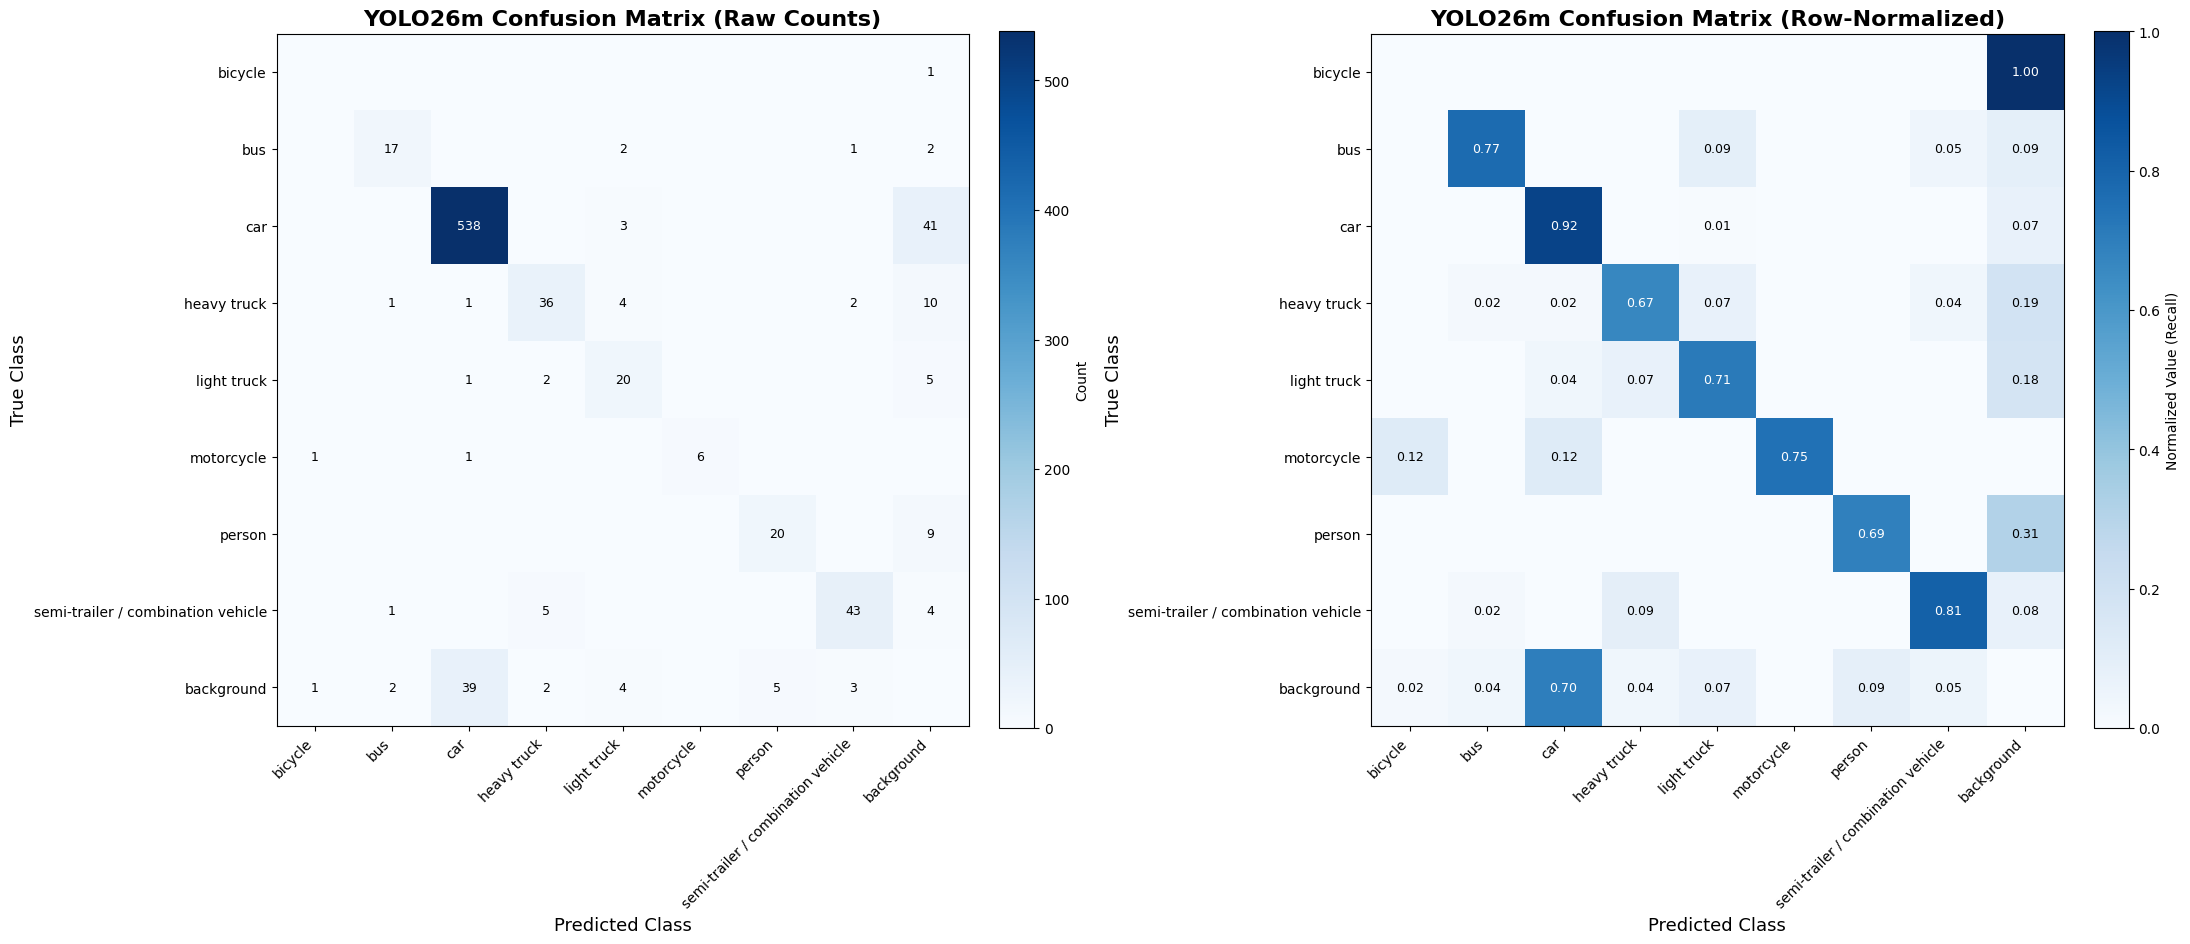

Matrices also saved by Ultralytics in: /content/runs/detect/val-2
confusion_matrix.png (original raw)
confusion_matrix_normalized.png (original column-normalized)


In [4]:

if hasattr(test_results, 'confusion_matrix') and test_results.confusion_matrix is not None:
    # Raw confusion matrix (counts)
    raw_cm = test_results.confusion_matrix.matrix
    # Convert to numpy if it's a torch tensor
    if hasattr(raw_cm, 'cpu'):
        raw_cm = raw_cm.cpu().numpy()
    else:
        raw_cm = np.asarray(raw_cm)

    # Get class names from the results
    if hasattr(test_results, 'names') and test_results.names:
        class_names = list(test_results.names.values())
    else:
        class_names = [f'Class {i}' for i in range(raw_cm.shape[0])]

    # === Handle extra background row/column ===
    nc = len(class_names)
    if raw_cm.shape[0] == nc + 1:
        class_names = class_names + ['background']
    elif raw_cm.shape[0] != nc:
        print(f'Matrix shape {raw_cm.shape} does not match {nc} classes. Using generic labels.')
        class_names = [f'Class {i}' for i in range(raw_cm.shape[0])]

    # Row-normalized matrix (recall-oriented)
    row_sums = raw_cm.sum(axis=1, keepdims=True)
    norm_cm = raw_cm.astype(np.float64) / (row_sums + 1e-9)

    # Create side-by-side plots
    fig, axes = plt.subplots(1, 2, figsize=(22, 11))

    # --- LEFT: RAW MATRIX ---
    im_raw = axes[0].imshow(raw_cm, interpolation='nearest', cmap='Blues')
    axes[0].set_title('YOLO26m Confusion Matrix (Raw Counts)', fontsize=16, fontweight='bold')
    axes[0].set_xlabel('Predicted Class', fontsize=13)
    axes[0].set_ylabel('True Class', fontsize=13)

    axes[0].set_xticks(np.arange(len(class_names)))
    axes[0].set_yticks(np.arange(len(class_names)))
    axes[0].set_xticklabels(class_names, rotation=45, ha='right', fontsize=10)
    axes[0].set_yticklabels(class_names, fontsize=10)

    plt.colorbar(im_raw, ax=axes[0], fraction=0.046, pad=0.04, label='Count')

    # Annotate cells – SKIP if value is exactly 0 (no number shown)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            value = int(raw_cm[i, j])
            if value > 0:
                color = 'white' if raw_cm[i, j] > raw_cm.max() * 0.6 else 'black'
                axes[0].text(j, i, str(value), ha='center', va='center', color=color, fontsize=9)

    # --- RIGHT: ROW-NORMALIZED MATRIX ---
    im_norm = axes[1].imshow(norm_cm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
    axes[1].set_title('YOLO26m Confusion Matrix (Row-Normalized)', fontsize=16, fontweight='bold')
    axes[1].set_xlabel('Predicted Class', fontsize=13)
    axes[1].set_ylabel('True Class', fontsize=13)

    axes[1].set_xticks(np.arange(len(class_names)))
    axes[1].set_yticks(np.arange(len(class_names)))
    axes[1].set_xticklabels(class_names, rotation=45, ha='right', fontsize=10)
    axes[1].set_yticklabels(class_names, fontsize=10)

    plt.colorbar(im_norm, ax=axes[1], fraction=0.046, pad=0.04, label='Normalized Value (Recall)')

    # Annotate cells – SKIP if value is exactly 0 (no number shown)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            value = norm_cm[i, j]
            if value > 0.0:
                color = 'white' if value > 0.6 else 'black'
                axes[1].text(j, i, f'{value:.2f}', ha='center', va='center', color=color, fontsize=9)

    plt.tight_layout()
    plt.show()


    # Optional: Ultralytics saved images
    save_dir = Path(test_results.save_dir)
    print(f"Matrices also saved by Ultralytics in: {save_dir}")
    print(f"confusion_matrix.png (original raw)")
    print(f"confusion_matrix_normalized.png (original column-normalized)")

else:
    print("✗ Could not find confusion_matrix data in test_results.")
    save_dir = Path(getattr(test_results, 'save_dir', 'runs/detect/val'))
    cm_raw_path = save_dir / 'confusion_matrix.png'
    cm_norm_path = save_dir / 'confusion_matrix_normalized.png'
    if cm_raw_path.exists() and cm_norm_path.exists():
        fig, axes = plt.subplots(1, 2, figsize=(20, 10))
        img_raw = cv2.cvtColor(cv2.imread(str(cm_raw_path)), cv2.COLOR_BGR2RGB)
        axes[0].imshow(img_raw)
        axes[0].set_title('YOLO26n Confusion Matrix (Raw Counts) [Fallback]', fontsize=15, fontweight='bold')
        axes[0].axis('off')
        img_norm = cv2.cvtColor(cv2.imread(str(cm_norm_path)), cv2.COLOR_BGR2RGB)
        axes[1].imshow(img_norm)
        axes[1].set_title('YOLO26n Confusion Matrix (Row-Normalized) [Fallback]', fontsize=15, fontweight='bold')
        axes[1].axis('off')
        plt.tight_layout()
        plt.show()
        print(f"Matrices loaded from: {save_dir}")
    else:
        print("✗ Confusion matrix images not found. Ensure 'plots=True' was used in model.val().")


## Examples of GT vs Pred
Displaying all images from the test set

In [ ]:
from ultralytics import YOLO
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
from IPython.display import clear_output

# ----------------------------- CONFIG -----------------------------
best_model_path = Path('/content/drive/MyDrive/yolo26n_results/YOLO26n_final.pt')
work_dir = Path('/content/drive/MyDrive/yolo_dataset')

# Load Model
model = YOLO(str(best_model_path))
class_names = model.names  # Dictionary mapping {id: "name"}

test_images_dir = work_dir / 'test' / 'images'
test_labels_dir = work_dir / 'test' / 'labels'

# Get all test images
test_images = sorted(list(test_images_dir.glob('*.jpg')) +
                     list(test_images_dir.glob('*.png')))

print(f"Found {len(test_images)} test images. Starting visualization...\n")

# ----------------------------- LOOP -----------------------------
for i, img_path in enumerate(test_images, 1):
    # Load image
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None: continue

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h_img, w_img, _ = img_rgb.shape

    # Run prediction
    results = model.predict(source=str(img_path),
                            imgsz=640,
                            conf=0.25,
                            verbose=False)

    # Load Ground Truth labels
    label_path = test_labels_dir / (img_path.stem + '.txt')
    gt_boxes = []
    if label_path.exists():
        with open(label_path, 'r') as f:
            for line in f:
                cls, x, y, w, h = map(float, line.strip().split())
                gt_boxes.append((int(cls), x, y, w, h))

    # Create side-by-side figure
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))

    # --- LEFT: Ground Truth ---
    # Draw GT boxes manually on a copy of the RGB image
    gt_display = img_rgb.copy()
    for cls_id, x_center, y_center, w, h in gt_boxes:
        # Get class name from model dictionary
        label_name = class_names.get(cls_id, f"ID {cls_id}")

        # Denormalize coordinates
        x1 = int((x_center - w/2) * w_img)
        y1 = int((y_center - h/2) * h_img)
        x2 = int((x_center + w/2) * w_img)
        y2 = int((y_center + h/2) * h_img)

        # Draw Box (Green)
        cv2.rectangle(gt_display, (x1, y1), (x2, y2), (0, 255, 0), 3)

        # Draw Label Background & Text
        label_txt = f"GT: {label_name}"
        (t_w, t_h), _ = cv2.getTextSize(label_txt, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        cv2.rectangle(gt_display, (x1, y1 - t_h - 10), (x1 + t_w, y1), (0, 255, 0), -1)
        cv2.putText(gt_display, label_txt, (x1, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)

    axes[0].imshow(gt_display)
    axes[0].set_title(f'Ground Truth ({len(gt_boxes)} objects)', fontsize=14, fontweight='bold')
    axes[0].axis('off')

    # --- RIGHT: Prediction (YOLO26) ---
    pred_img_bgr = results[0].plot() # Ultralytics handles plotting here
    axes[1].imshow(cv2.cvtColor(pred_img_bgr, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f'Prediction ({len(results[0].boxes)} detected)', fontsize=14, fontweight='bold')
    axes[1].axis('off')

    plt.suptitle(f'Image {i}/{len(test_images)} — {img_path.name}',
                 fontsize=18, fontweight='bold', y=0.95)

    plt.tight_layout()
    plt.show()



Output hidden; open in https://colab.research.google.com to view.

## ONNX export

In [ ]:
from ultralytics import YOLO


model1_path = Path('/content/drive/MyDrive/yolo26n_results/YOLO26n_final.pt')
model1 = YOLO(str(model1_path))

model1.export(format="onnx", imgsz=640)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO26n summary (fused): 122 layers, 2,376,396 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/yolo26n_results/YOLO26n_final.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.1 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 269ms
Prepared 4 packages in 1.37s
Installed 4 packages in 314ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime==1.25.0
 + onnxslim==0.1.91

requirements: AutoUpdate success ✅ 2.5s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...


/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: slimming with onnxslim 0.1.91...
ONNX: export success ✅ 4.5s, saved as '/content/drive/MyDrive/yolo26n_results/YOLO26n_final.onnx' (9.4 MB)

Export complete (5.5s)
Results saved to /content/drive/MyDrive/yolo26n_results
Predict:         yolo predict task=detect model=/content/drive/MyDrive/yolo26n_results/YOLO26n_final.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/drive/MyDrive/yolo26n_results/YOLO26n_final.onnx imgsz=640 data=/content/drive/MyDrive/yolo_dataset/data.yaml  
Visualize:       https://netron.app


'/content/drive/MyDrive/yolo26n_results/YOLO26n_final.onnx'